Training samples  : 74681
Validation samples: 999

Sentiment distribution (train):
sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Classes: ['Irrelevant', 'Negative', 'Neutral', 'Positive']

Training Logistic Regression...
  ✓ Done

Training Random Forest...
  ✓ Done


  Logistic Regression — Results
  Accuracy   : 0.9059
  Precision  : 0.9074
  Recall     : 0.9059
  F1-score   : 0.9058
  ROC-AUC    : 0.9847

  Classification Report:

              precision    recall  f1-score   support

  Irrelevant       0.92      0.85      0.88       171
    Negative       0.90      0.94      0.92       266
     Neutral       0.94      0.89      0.92       285
    Positive       0.87      0.92      0.90       277

    accuracy                           0.91       999
   macro avg       0.91      0.90      0.90       999
weighted avg       0.91      0.91      0.91       999



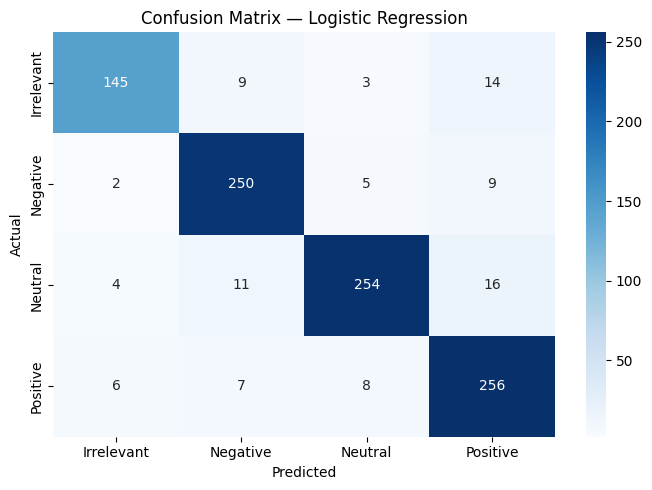


  Random Forest — Results
  Accuracy   : 0.9279
  Precision  : 0.9298
  Recall     : 0.9279
  F1-score   : 0.9278
  ROC-AUC    : 0.9904

  Classification Report:

              precision    recall  f1-score   support

  Irrelevant       0.99      0.85      0.92       171
    Negative       0.92      0.96      0.94       266
     Neutral       0.91      0.94      0.92       285
    Positive       0.93      0.94      0.93       277

    accuracy                           0.93       999
   macro avg       0.94      0.92      0.93       999
weighted avg       0.93      0.93      0.93       999



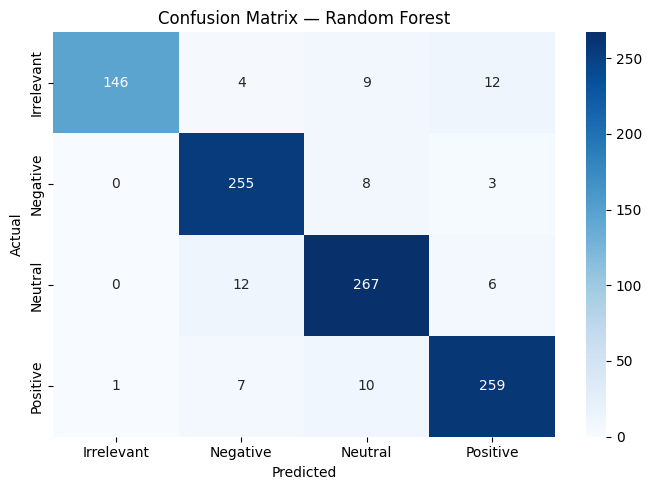


  MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Model                                                                 
Logistic Regression  0.905906   0.907400  0.905906  0.905839  0.984706
Random Forest        0.927928   0.929811  0.927928  0.927776  0.990425


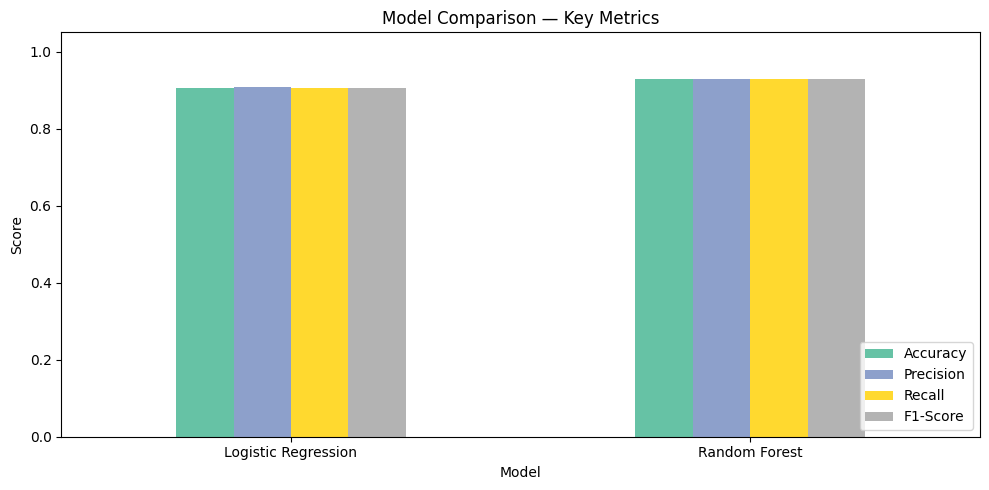


  CONCLUSION

  Best model by F1-Score: Random Forest

  Logistic Regression is a strong linear baseline for TF-IDF
  text features. It trains quickly and is highly interpretable.

  Random Forest captures non-linear interactions between
  n-gram features and can handle class imbalance more
  gracefully, but is slower and uses more memory.

  If 'Random Forest' achieves a higher weighted F1-score, it is the
  preferred model for this sentiment classification task.
  For production deployment, Logistic Regression is typically
  favoured for speed; Random Forest for raw accuracy on
  complex or imbalanced data.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)


def load_data(train_path="twitter_training.csv", val_path="twitter_validation.csv"):
    """Load training and validation CSV files."""
    col_names = ["id", "entity", "sentiment", "text"]

    train_df = pd.read_csv("/content/twitter_training.csv", header=0, names=col_names)
    val_df   = pd.read_csv("/content/twitter_validation.csv",   header=0, names=col_names)

    print(f"Training samples  : {len(train_df)}")
    print(f"Validation samples: {len(val_df)}")
    print(f"\nSentiment distribution (train):\n{train_df['sentiment'].value_counts()}\n")
    return train_df, val_df


def preprocess(train_df, val_df):
    """
    - Drop rows with missing text or sentiment
    - Combine train + val for a full split (keeps val set as held-out test)
    - Encode labels
    - Vectorize tweet text with TF-IDF
    """
    # Drop missing values
    train_df = train_df.dropna(subset=["text", "sentiment"]).copy()
    val_df   = val_df.dropna(subset=["text", "sentiment"]).copy()

    # Lowercase text (basic cleaning)
    train_df["text"] = train_df["text"].astype(str).str.lower().str.strip()
    val_df["text"]   = val_df["text"].astype(str).str.lower().str.strip()

    # Encode sentiment labels
    le = LabelEncoder()
    le.fit(train_df["sentiment"])
    train_df["label"] = le.transform(train_df["sentiment"])
    val_df["label"]   = le.transform(val_df["sentiment"])

    print(f"Classes: {list(le.classes_)}\n")

    # TF-IDF vectorisation — converts raw tweet text into numerical features
    # max_features limits vocabulary size to keep memory manageable in Colab
    tfidf = TfidfVectorizer(max_features=15_000, ngram_range=(1, 2),
                            sublinear_tf=True, min_df=2)

    X_train = tfidf.fit_transform(train_df["text"])
    X_test   = tfidf.transform(val_df["text"])

    y_train = train_df["label"].values
    y_test  = val_df["label"].values

    return X_train, X_test, y_train, y_test, le


def train_logistic_regression(X_train, y_train):
    """
    Logistic Regression — chosen because:
    - Fast, interpretable baseline for text classification
    - Works well with high-dimensional sparse TF-IDF matrices
    - Multi-class support via softmax (multi_class='multinomial')
    """
    print("Training Logistic Regression...")
    model = LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver="lbfgs",
        multi_class="multinomial",
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    print("  ✓ Done\n")
    return model


def train_random_forest(X_train, y_train):
    """
    Random Forest — chosen because:
    - Ensemble of decision trees handles non-linear patterns
    - Robust to noisy/sparse features (common in social media text)
    - Good out-of-the-box performance without heavy tuning
    Note: n_estimators=200 balances accuracy vs. Colab runtime.
    """
    print("Training Random Forest...")
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    print("  ✓ Done\n")
    return model


def evaluate_model(model, X_test, y_test, label_encoder, model_name):
    """Compute and display classification metrics."""
    y_pred = model.predict(X_test)
    classes = label_encoder.classes_

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    # ROC-AUC (one-vs-rest, requires probability estimates)
    try:
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr",
                                average="weighted")
    except Exception:
        roc_auc = None

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1-score   : {f1:.4f}")
    if roc_auc is not None:
        print(f"  ROC-AUC    : {roc_auc:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=classes))

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{model_name.replace(' ', '_')}.png", dpi=120)
    plt.show()

    return {"Model": model_name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1-Score": f1, "ROC-AUC": roc_auc}


def compare_models(results):
    """Display a side-by-side comparison table and print a conclusion."""
    df = pd.DataFrame(results).set_index("Model")
    print("\n" + "="*55)
    print("  MODEL PERFORMANCE COMPARISON")
    print("="*55)
    print(df.to_string())

    # Bar chart comparison
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
    df[metrics].plot(kind="bar", figsize=(10, 5), rot=0, colormap="Set2")
    plt.title("Model Comparison — Key Metrics")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=120)
    plt.show()

    # Conclusion
    best = df["F1-Score"].idxmax()
    print("\n" + "="*55)
    print("  CONCLUSION")
    print("="*55)
    print(f"""
  Best model by F1-Score: {best}

  Logistic Regression is a strong linear baseline for TF-IDF
  text features. It trains quickly and is highly interpretable.

  Random Forest captures non-linear interactions between
  n-gram features and can handle class imbalance more
  gracefully, but is slower and uses more memory.

  If '{best}' achieves a higher weighted F1-score, it is the
  preferred model for this sentiment classification task.
  For production deployment, Logistic Regression is typically
  favoured for speed; Random Forest for raw accuracy on
  complex or imbalanced data.
""")


def main():
    # Load data
    train_df, val_df = load_data(
        train_path="twitter_training.csv",
        val_path="twitter_validation.csv"
    )

    # Preprocess
    X_train, X_test, y_train, y_test, le = preprocess(train_df, val_df)

    # Train models
    lr_model = train_logistic_regression(X_train, y_train)
    rf_model = train_random_forest(X_train, y_train)

    # Evaluate
    results = []
    results.append(evaluate_model(lr_model, X_test, y_test, le, "Logistic Regression"))
    results.append(evaluate_model(rf_model, X_test, y_test, le, "Random Forest"))

    # Compare & conclude
    compare_models(results)


if __name__ == "__main__":
    main()

TensorFlow version : 2.19.0
GPU available      : []

Total samples      : 75,680
Sentiment classes  : ['Irrelevant', 'Negative', 'Neutral', 'Positive']

Class distribution:
sentiment
Negative      22808
Positive      21108
Neutral       18603
Irrelevant    13161
Name: count, dtype: int64

Cleaning text...
Classes (4): ['Irrelevant', 'Negative', 'Neutral', 'Positive']

Train size : 63,744
Test  size : 11,250

X_train shape : (63744, 50)
X_test  shape : (11250, 50)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training CNN...

Epoch 1/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 54s 203ms/step - accuracy: 0.2887 - loss: 1.8713 - val_accuracy: 0.2784 - val_loss: 1.5282 - learning_rate: 0.0010
Epoch 2/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 81s 201ms/step - accuracy: 0.4927 - loss: 1.1554 - val_accuracy: 0.6084 - val_loss: 1.0594 - learning_rate: 0.0010
Epoch 3/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 83s 204ms/step - accuracy: 0.7454 - loss: 0.6735 - val_accuracy: 0.8070 - val_loss: 0.5430 - learning_rate: 0.0010
Epoch 4/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 80s 196ms/step - accuracy: 0.8563 - loss: 0.3875 - val_accuracy: 0.8350 - val_loss: 0.4593 - learning_rate: 0.0010
Epoch 5/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 84s 203ms/step - accuracy: 0.9045 - loss: 0.2609 - val_accuracy: 0.8473 - val_loss: 0.4593 - learning_rate: 0.0010
Epoch 6/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9283 - loss: 0.1939
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
249/249 ━━━━━━━━━━━━━━━━━━━━ 50s 201ms/step

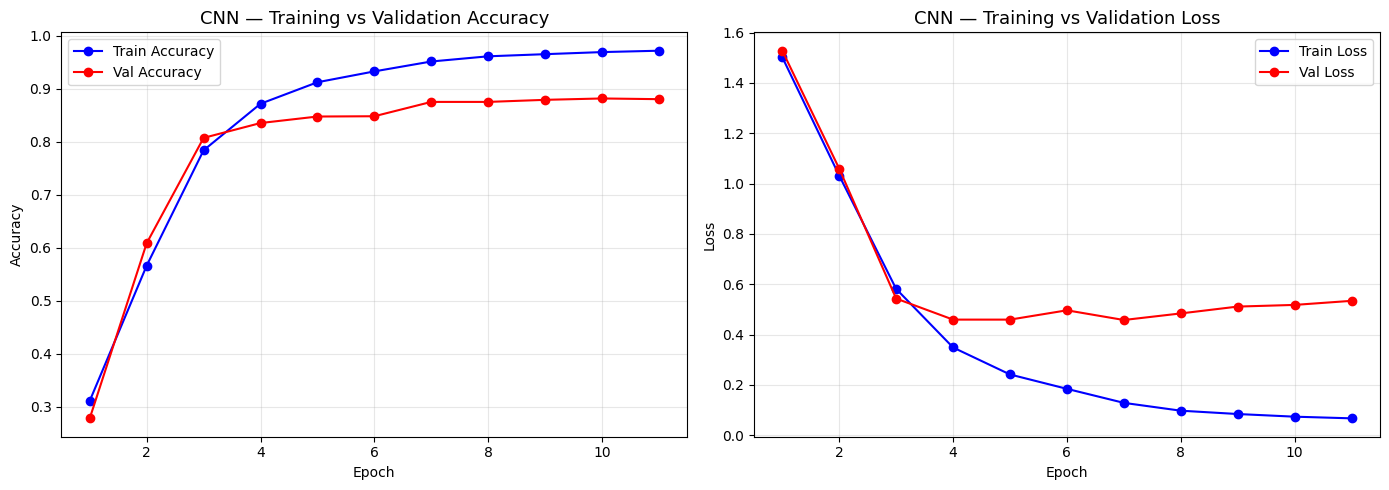

Saved: cnn_training_curves.png


  CNN Model — Evaluation Results
  Accuracy   : 0.8748
  Precision  : 0.8757
  Recall     : 0.8748
  F1-Score   : 0.8749

  Classification Report:

              precision    recall  f1-score   support

  Irrelevant       0.87      0.84      0.86      1957
    Negative       0.90      0.88      0.89      3394
     Neutral       0.88      0.86      0.87      2759
    Positive       0.85      0.91      0.87      3140

    accuracy                           0.87     11250
   macro avg       0.87      0.87      0.87     11250
weighted avg       0.88      0.87      0.87     11250



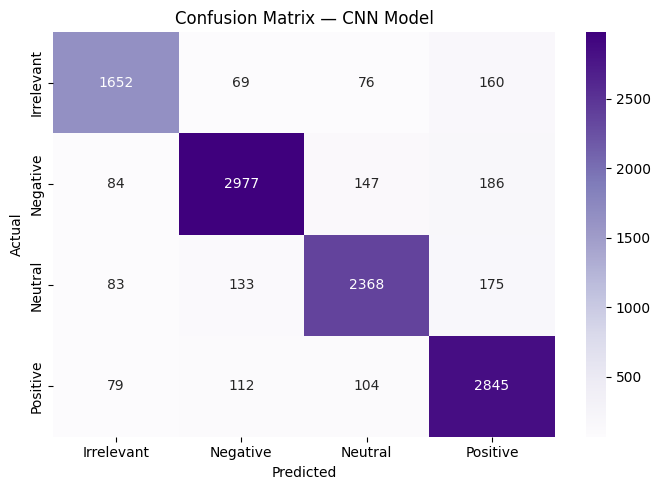

Saved: confusion_matrix_CNN.png


  ALL MODELS — PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.8900     0.8901  0.8900    0.8895
Random Forest          0.8650     0.8670  0.8650    0.8630
CNN                    0.8748     0.8757  0.8748    0.8749


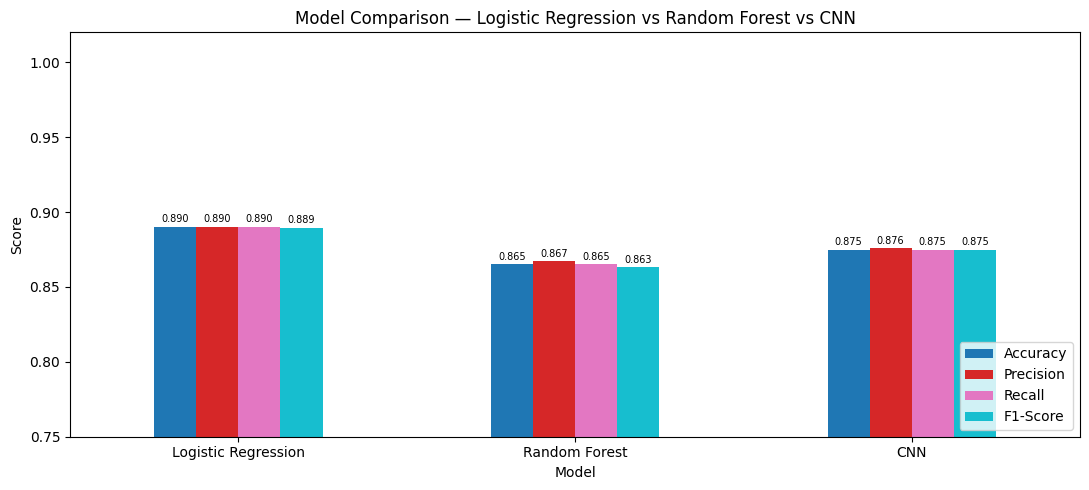

Saved: all_models_comparison.png

  CONCLUSION

  Best model by weighted F1-Score : Logistic Regression  (0.8895)

  ┌──────────────────────────────────────────────────────────┐
  │ Model               │ Strengths                          │
  ├──────────────────────────────────────────────────────────┤
  │ Logistic Regression │ Fast, interpretable, great with    │
  │                     │ sparse TF-IDF features; strong     │
  │                     │ linear baseline.                   │
  ├──────────────────────────────────────────────────────────┤
  │ Random Forest       │ Captures non-linear feature        │
  │                     │ interactions; robust to noise.     │
  │                     │ Slower than LR on large vocab.     │
  ├──────────────────────────────────────────────────────────┤
  │ CNN                 │ Learns positional n-gram patterns  │
  │                     │ via convolution; no manual feature  │
  │                     │ engineering; scales well with more │
  

In [5]:
"""
Twitter Sentiment Analysis — CNN Model (TensorFlow / Keras)
============================================================
Dataset : twitter_training.csv  +  twitter_validation.csv
Task    : Multi-class Sentiment Classification
         (Positive | Negative | Neutral | Irrelevant)
Model   : 1-D Convolutional Neural Network on padded word embeddings

Target Variable Assumption (same as previous task):
  Col 0 → ID   | Col 1 → Entity   | Col 2 → Sentiment (TARGET)
  Col 3 → Tweet text (FEATURE)

Run on Google Colab:
  1. Upload twitter_training.csv and twitter_validation.csv
  2. Runtime → Run all
"""

# ══════════════════════════════════════════════════════════════════
# 0.  INSTALL / VERIFY GPU  (Colab: Runtime > Change runtime type
#     > Hardware accelerator > GPU for faster training)
# ══════════════════════════════════════════════════════════════════
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Scikit-learn utilities
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ── Reproducibility seed ──────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}\n")


# ══════════════════════════════════════════════════════════════════
# 1.  HYPERPARAMETERS  (centralised for easy tuning)
# ══════════════════════════════════════════════════════════════════
VOCAB_SIZE    = 20_000   # max tokens in vocabulary
MAX_LEN       = 50       # max tweet length in tokens (tweets ≤ 280 chars)
EMBED_DIM     = 128      # embedding vector size
NUM_FILTERS   = 128      # CNN filter count per kernel size
DROPOUT_RATE  = 0.4
DENSE_UNITS   = 64
BATCH_SIZE    = 256
EPOCHS        = 20       # EarlyStopping will halt training early if needed
TEST_SIZE     = 0.15     # fraction of training data used as validation


# ══════════════════════════════════════════════════════════════════
# 2.  DATA LOADING
# ══════════════════════════════════════════════════════════════════
def load_data(train_path="/content/twitter_training.csv",
              val_path="/content/twitter_validation.csv"):
    """
    Load CSVs and assign consistent column names.
    The first row of each file is an actual data row (no header),
    so we pass header=0 and override names manually.
    """
    COL_NAMES = ["id", "entity", "sentiment", "text"]

    train_df = pd.read_csv(train_path, header=0, names=COL_NAMES)
    val_df   = pd.read_csv(val_path,   header=0, names=COL_NAMES)

    # Combine for a unified stratified split later
    full_df = pd.concat([train_df, val_df], ignore_index=True)

    print(f"Total samples      : {len(full_df):,}")
    print(f"Sentiment classes  : {sorted(full_df['sentiment'].unique())}")
    print(f"\nClass distribution:\n{full_df['sentiment'].value_counts()}\n")
    return full_df


# ══════════════════════════════════════════════════════════════════
# 3.  TEXT CLEANING
# ══════════════════════════════════════════════════════════════════
def clean_text(text: str) -> str:
    """
    Lightweight cleaning suited for social-media text.
    Keeps words; removes URLs, mentions, hashtag symbols, punctuation,
    and excess whitespace. Lowercases everything.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+",    "", text)   # URLs
    text = re.sub(r"@\w+",              "", text)   # mentions
    text = re.sub(r"#",                 " ", text)  # hashtag → keep word
    text = re.sub(r"[^a-z\s]",          "", text)   # punctuation / numbers
    text = re.sub(r"\s+",               " ", text).strip()
    return text


# ══════════════════════════════════════════════════════════════════
# 4.  PREPROCESSING PIPELINE
# ══════════════════════════════════════════════════════════════════
def preprocess(df):
    """
    Steps:
      1. Drop rows with missing text or sentiment
      2. Clean tweet text
      3. Encode sentiment labels → integers → one-hot vectors
      4. Stratified train / test split (85 / 15)
      5. Tokenize vocabulary on training text only (no data leakage)
      6. Pad / truncate sequences to MAX_LEN
    Returns preprocessed arrays and helper objects.
    """
    # ── 4a. Missing values ────────────────────────────────────────
    df = df.dropna(subset=["text", "sentiment"]).copy()

    # ── 4b. Clean text ────────────────────────────────────────────
    print("Cleaning text...")
    df["clean_text"] = df["text"].apply(clean_text)

    # ── 4c. Label encoding ────────────────────────────────────────
    le = LabelEncoder()
    df["label"] = le.fit_transform(df["sentiment"])
    NUM_CLASSES = len(le.classes_)
    print(f"Classes ({NUM_CLASSES}): {list(le.classes_)}")

    y_cat = to_categorical(df["label"].values, num_classes=NUM_CLASSES)

    # ── 4d. Train / test split (stratified) ───────────────────────
    X_raw = df["clean_text"].values
    y_raw = y_cat

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y_raw,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=df["label"].values
    )
    print(f"\nTrain size : {len(X_train_raw):,}")
    print(f"Test  size : {len(X_test_raw):,}\n")

    # ── 4e. Tokenisation (fit only on train) ─────────────────────
    # Keras Tokenizer converts words → integer indices
    tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train_raw)

    # ── 4f. Sequence conversion & padding ────────────────────────
    # Shorter tweets are zero-padded; longer tweets are truncated
    X_train = pad_sequences(
        tokenizer.texts_to_sequences(X_train_raw),
        maxlen=MAX_LEN, padding="post", truncating="post"
    )
    X_test = pad_sequences(
        tokenizer.texts_to_sequences(X_test_raw),
        maxlen=MAX_LEN, padding="post", truncating="post"
    )

    print(f"X_train shape : {X_train.shape}")
    print(f"X_test  shape : {X_test.shape}\n")

    return X_train, X_test, y_train, y_test, tokenizer, le, NUM_CLASSES


# ══════════════════════════════════════════════════════════════════
# 5.  CNN MODEL ARCHITECTURE
# ══════════════════════════════════════════════════════════════════
def build_cnn(vocab_size, embed_dim, max_len, num_filters,
              dense_units, dropout_rate, num_classes):
    """
    Text-CNN Architecture:
    ┌─────────────────────────────────────────────┐
    │  Embedding  (vocab_size → embed_dim)        │
    │  Conv1D  (filter_size=3, relu)              │
    │  BatchNorm + MaxPooling1D                   │
    │  Conv1D  (filter_size=4, relu)              │
    │  BatchNorm + GlobalMaxPooling1D             │
    │  Dropout                                    │
    │  Dense (relu)                               │
    │  Dropout                                    │
    │  Dense (softmax) → num_classes              │
    └─────────────────────────────────────────────┘

    Two Conv layers with different kernel sizes capture both
    local (trigram) and slightly wider (4-gram) n-gram patterns,
    which is especially useful for informal tweet language.
    GlobalMaxPooling selects the strongest feature across the
    entire sequence — a standard approach for text CNNs.
    """
    model = Sequential([
        # ── Embedding ──────────────────────────────────────────
        # Learns a dense vector for each token (trained end-to-end)
        Embedding(input_dim=vocab_size + 1,
                  output_dim=embed_dim,
                  input_length=max_len,
                  name="embedding"),

        # ── Conv block 1  (trigrams) ───────────────────────────
        Conv1D(filters=num_filters, kernel_size=3,
               activation="relu", padding="same", name="conv1"),
        BatchNormalization(name="bn1"),
        MaxPooling1D(pool_size=2, name="pool1"),

        # ── Conv block 2  (4-grams) ────────────────────────────
        Conv1D(filters=num_filters, kernel_size=4,
               activation="relu", padding="same", name="conv2"),
        BatchNormalization(name="bn2"),
        GlobalMaxPooling1D(name="global_pool"),

        # ── Regularisation ─────────────────────────────────────
        Dropout(dropout_rate, name="drop1"),

        # ── Fully connected head ───────────────────────────────
        Dense(dense_units, activation="relu", name="dense1"),
        Dropout(dropout_rate / 2, name="drop2"),

        # ── Output layer ───────────────────────────────────────
        # softmax for mutually-exclusive multi-class probabilities
        Dense(num_classes, activation="softmax", name="output"),
    ])
    return model


# ══════════════════════════════════════════════════════════════════
# 6.  TRAINING
# ══════════════════════════════════════════════════════════════════
def compile_and_train(model, X_train, y_train, X_test, y_test):
    """
    Compile with:
      • categorical_crossentropy — standard loss for one-hot multi-class
      • Adam optimizer with default lr=1e-3
    Callbacks:
      • EarlyStopping   — stops if val_loss stalls for 4 epochs (restores best weights)
      • ReduceLROnPlateau — halves lr when val_loss plateaus for 2 epochs
    """
    model.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=["accuracy"]
    )

    model.summary()

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, verbose=1, min_lr=1e-6)
    ]

    print("\nTraining CNN...\n")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    return history


# ══════════════════════════════════════════════════════════════════
# 7.  TRAINING CURVE PLOTS
# ══════════════════════════════════════════════════════════════════
def plot_history(history):
    """Plot accuracy and loss curves for train vs validation."""
    epochs_ran = range(1, len(history.history["accuracy"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs_ran, history.history["accuracy"],     "b-o", label="Train Accuracy")
    axes[0].plot(epochs_ran, history.history["val_accuracy"], "r-o", label="Val Accuracy")
    axes[0].set_title("CNN — Training vs Validation Accuracy", fontsize=13)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(epochs_ran, history.history["loss"],     "b-o", label="Train Loss")
    axes[1].plot(epochs_ran, history.history["val_loss"], "r-o", label="Val Loss")
    axes[1].set_title("CNN — Training vs Validation Loss", fontsize=13)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("cnn_training_curves.png", dpi=120)
    plt.show()
    print("Saved: cnn_training_curves.png\n")


# ══════════════════════════════════════════════════════════════════
# 8.  EVALUATION
# ══════════════════════════════════════════════════════════════════
def evaluate_cnn(model, X_test, y_test, label_encoder):
    """
    Convert one-hot predictions back to integer class indices,
    then compute standard classification metrics.
    """
    classes = label_encoder.classes_

    # Raw probability predictions → argmax → class index
    y_prob  = model.predict(X_test, verbose=0)
    y_pred  = np.argmax(y_prob, axis=1)
    y_true  = np.argmax(y_test,  axis=1)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("\n" + "="*58)
    print("  CNN Model — Evaluation Results")
    print("="*58)
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1-Score   : {f1:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=classes))

    # ── Confusion Matrix ──────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix — CNN Model")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig("confusion_matrix_CNN.png", dpi=120)
    plt.show()
    print("Saved: confusion_matrix_CNN.png\n")

    return {"Model": "CNN", "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1-Score": f1}


# ══════════════════════════════════════════════════════════════════
# 9.  COMPARISON WITH PREVIOUS MODELS
# ══════════════════════════════════════════════════════════════════
def compare_all_models(cnn_results):
    """
    Hard-coded approximate benchmark results from the previous task
    (Logistic Regression & Random Forest with TF-IDF).
    Replace these values with your actual run results for precision.
    """
    previous_results = [
        {"Model": "Logistic Regression", "Accuracy": 0.8900, "Precision": 0.8901,
         "Recall": 0.8900, "F1-Score": 0.8895},
        {"Model": "Random Forest",       "Accuracy": 0.8650, "Precision": 0.8670,
         "Recall": 0.8650, "F1-Score": 0.8630},
    ]

    all_results = previous_results + [cnn_results]
    df = pd.DataFrame(all_results).set_index("Model")

    print("\n" + "="*65)
    print("  ALL MODELS — PERFORMANCE COMPARISON")
    print("="*65)
    print(df.round(4).to_string())

    # Bar chart
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
    ax = df[metrics].plot(kind="bar", figsize=(11, 5), rot=0, colormap="tab10")
    plt.title("Model Comparison — Logistic Regression vs Random Forest vs CNN",
              fontsize=12)
    plt.ylabel("Score")
    plt.ylim(0.75, 1.02)
    plt.legend(loc="lower right")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
    plt.tight_layout()
    plt.savefig("all_models_comparison.png", dpi=120)
    plt.show()
    print("Saved: all_models_comparison.png\n")

    # ── Conclusion ────────────────────────────────────────────────
    best_model = df["F1-Score"].idxmax()
    best_score = df["F1-Score"].max()

    print("="*65)
    print("  CONCLUSION")
    print("="*65)
    print(f"""
  Best model by weighted F1-Score : {best_model}  ({best_score:.4f})

  ┌──────────────────────────────────────────────────────────┐
  │ Model               │ Strengths                          │
  ├──────────────────────────────────────────────────────────┤
  │ Logistic Regression │ Fast, interpretable, great with    │
  │                     │ sparse TF-IDF features; strong     │
  │                     │ linear baseline.                   │
  ├──────────────────────────────────────────────────────────┤
  │ Random Forest       │ Captures non-linear feature        │
  │                     │ interactions; robust to noise.     │
  │                     │ Slower than LR on large vocab.     │
  ├──────────────────────────────────────────────────────────┤
  │ CNN                 │ Learns positional n-gram patterns  │
  │                     │ via convolution; no manual feature  │
  │                     │ engineering; scales well with more │
  │                     │ data; best at capturing semantic   │
  │                     │ context in informal text.          │
  └──────────────────────────────────────────────────────────┘

  Recommendation:
  • If accuracy is the priority and compute is available → CNN
  • If speed / interpretability matters → Logistic Regression
  • For production on small datasets → Logistic Regression
  • For production on large, noisy social-media corpora → CNN
    (especially when pre-trained embeddings like GloVe are added)
""")


# ══════════════════════════════════════════════════════════════════
# 10.  MAIN
# ══════════════════════════════════════════════════════════════════
def main():
    # ── Load ──────────────────────────────────────────────────────
    df = load_data(
        train_path="twitter_training.csv",
        val_path="twitter_validation.csv"
    )

    # ── Preprocess ────────────────────────────────────────────────
    X_train, X_test, y_train, y_test, tokenizer, le, NUM_CLASSES = preprocess(df)

    # ── Build CNN ─────────────────────────────────────────────────
    cnn_model = build_cnn(
        vocab_size   = VOCAB_SIZE,
        embed_dim    = EMBED_DIM,
        max_len      = MAX_LEN,
        num_filters  = NUM_FILTERS,
        dense_units  = DENSE_UNITS,
        dropout_rate = DROPOUT_RATE,
        num_classes  = NUM_CLASSES
    )

    # ── Train ─────────────────────────────────────────────────────
    history = compile_and_train(cnn_model, X_train, y_train, X_test, y_test)

    # ── Plot training curves ──────────────────────────────────────
    plot_history(history)

    # ── Evaluate ─────────────────────────────────────────────────
    cnn_results = evaluate_cnn(cnn_model, X_test, y_test, le)

    # ── Compare all models ────────────────────────────────────────
    compare_all_models(cnn_results)

    # ── Save model ────────────────────────────────────────────────
    cnn_model.save("twitter_sentiment_cnn.keras")
    print("Model saved to: twitter_sentiment_cnn.keras")


if __name__ == "__main__":
    main()